In [1]:
!nvidia-smi

Sun Jul 26 05:37:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q gdown supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 11.7 MB/s eta 0:00:00


In [3]:
!pip install -q git+https://github.com/roboflow/sports.git

  Preparing metadata (setup.py) ... done


In [4]:
import os
os.environ["ONNXRUNTIME_EXECUTION_PROVIDERS"] = "[CUDAExecutionProvider]"

In [5]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.3 MB/s eta 0:00:00


In [6]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/newMini/model/best.pt")

model.info()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model summary: 210 layers, 68,156,460 parameters, 0 gradients, 258.1 GFLOPs


(210, 68156460, 0, 258.13867519999997)

# Team Classifier using KMeans
- This is basically what happening inside the TeamClassifier class in sports.common.team

In [ ]:
from torchvision.transforms.functional import crop
from tqdm import tqdm
INPUT_VIDEO = '../input_videos/test-11.mp4'

STRIDE = 30
PLAYER_ID = 2

def extract_crops(video_path):
    frame_generator = sv.get_video_frames_generator(INPUT_VIDEO, stride=STRIDE)

    crops = []
    for frame in tqdm(frame_generator, desc='Collecting crops'):
      result = model.predict(frame, conf=0.3)[0]
      detections = sv.Detections.from_ultralytics(result)
      detections = detections.with_nms(threshold=0.5, class_agnostic=True)
      detections = detections[detections.class_id == PLAYER_ID]
      crops += [
          sv.crop_image(frame, xyxy)
          for xyxy in detections.xyxy
      ]
    return crops

In [47]:
crops = extract_crops(INPUT_VIDEO)


0: 736x1280 21 players, 2 referees, 183.7ms
Speed: 14.9ms preprocess, 183.7ms inference, 2.7ms postprocess per image at shape (1, 3, 736, 1280)



0: 736x1280 1 ball, 20 players, 2 referees, 152.8ms
Speed: 18.0ms preprocess, 152.8ms inference, 2.2ms postprocess per image at shape (1, 3, 736, 1280)



0: 736x1280 1 ball, 20 players, 2 referees, 147.1ms
Speed: 28.3ms preprocess, 147.1ms inference, 2.0ms postprocess per image at shape (1, 3, 736, 1280)



0: 736x1280 1 ball, 1 goalkeeper, 20 players, 2 referees, 148.9ms
Speed: 23.0ms preprocess, 148.9ms inference, 4.0ms postprocess per image at shape (1, 3, 736, 1280)



0: 736x1280 1 ball, 1 goalkeeper, 20 players, 2 referees, 146.8ms
Speed: 46.0ms preprocess, 146.8ms inference, 12.1ms postprocess per image at shape (1, 3, 736, 1280)


...


0: 736x1280 20 players, 3 referees, 151.8ms
Speed: 15.4ms preprocess, 151.8ms inference, 2.1ms postprocess per image at shape (1, 3, 736, 1280)



0: 736x1280 20 players, 3 referees, 151.0ms
Speed: 17.0ms preprocess, 151.0ms inference, 4.1ms postprocess per image at shape (1, 3, 736, 1280)



0: 736x1280 20 players, 3 referees, 151.0ms
Speed: 16.7ms preprocess, 151.0ms inference, 2.3ms postprocess per image at shape (1, 3, 736, 1280)



0: 736x1280 1 ball, 1 goalkeeper, 20 players, 3 referees, 150.7ms
Speed: 18.6ms preprocess, 150.7ms inference, 4.0ms postprocess per image at shape (1, 3, 736, 1280)



0: 736x1280 1 ball, 1 goalkeeper, 20 players, 3 referees, 150.0ms
Speed: 16.9ms preprocess, 150.0ms inference, 4.3ms postprocess per image at shape (1, 3, 736, 1280)


In [40]:
len(crops)

499

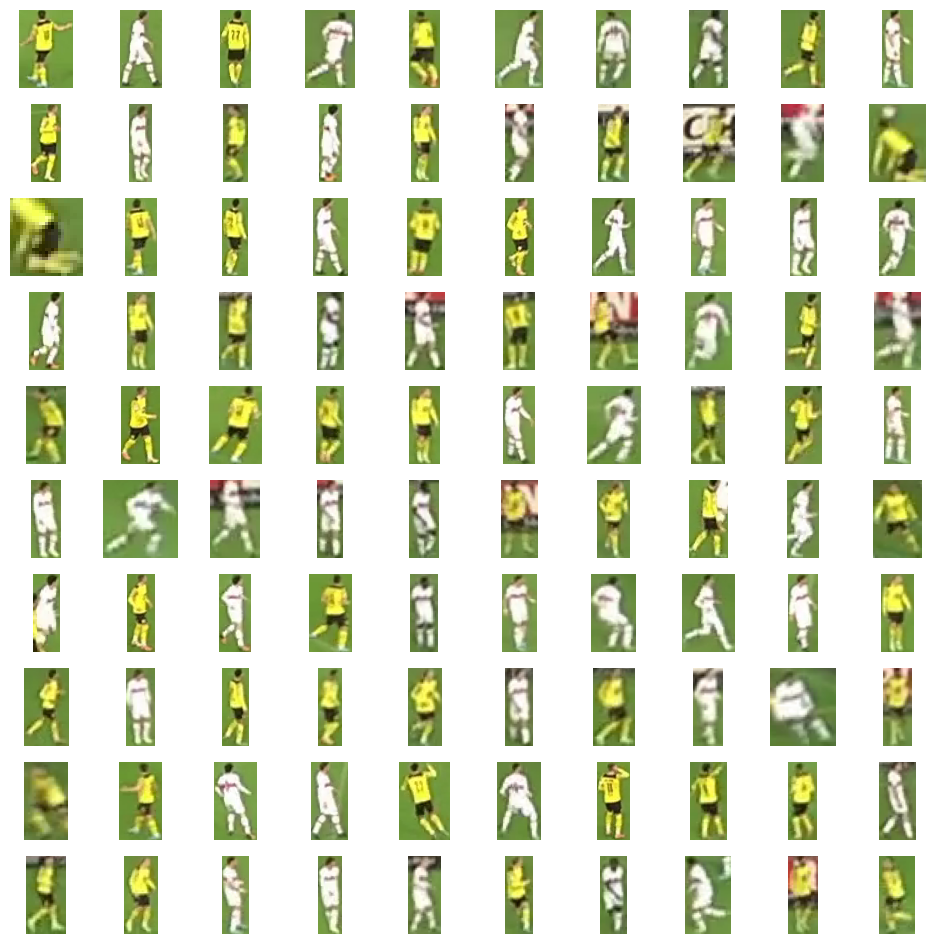

In [ ]:
import supervision as sv
sv.plot_images_grid(crops[:100], grid_size=(10, 10))

In [43]:
import torch
from transformers import AutoProcessor, SiglipVisionModel

SIGLIP_MODEL_PATH = 'google/siglip-base-patch16-224'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EMBEDDINGS_MODEL = SiglipVisionModel.from_pretrained(SIGLIP_MODEL_PATH).to(DEVICE)
EMBEDDINGS_PROCESSOR = AutoProcessor.from_pretrained(SIGLIP_MODEL_PATH)

config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  813MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.lay

...

tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  798kB            

spiece.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

In [48]:
from more_itertools import chunked
import numpy as np

BATCH_SIZE = 32

crops = [sv.cv2_to_pillow(crop) for crop in crops]
batches = chunked(crops, BATCH_SIZE)
data = []

with torch.no_grad():
    for batch in tqdm(batches, desc='Embeddings Extractions'):
        inputs = EMBEDDINGS_PROCESSOR(images=batch, return_tensors='pt').to(DEVICE)
        outputs = EMBEDDINGS_MODEL(**inputs)
        embeddings = torch.mean(outputs.last_hidden_state, dim=1).cpu().detach().numpy()
        data.append(embeddings)

data = np.concatenate(data)

Embeddings Extractions: 16it [00:08,  1.96it/s]


In [49]:
data.shape

(499, 768)

In [50]:
import umap
from sklearn.cluster import KMeans

REDUCER = umap.UMAP(n_components=3)
CLUSTERING_MODEL = KMeans(n_clusters=2)

In [51]:
projections = REDUCER.fit_transform(data)
projections.shape

(499, 3)

In [52]:
clusters = CLUSTERING_MODEL.fit_predict(projections)

In [53]:
clusters[:10]

array([0, 1, 0, 1, 0, 1, 1, 1, 0, 1], dtype=int32)

In [55]:
team_0 = [
    crop
    for crop, cluster in zip(crops, clusters)
    if cluster == 0
]

team_1 = [
    crop
    for crop, cluster in zip(crops, clusters)
    if cluster == 1
]

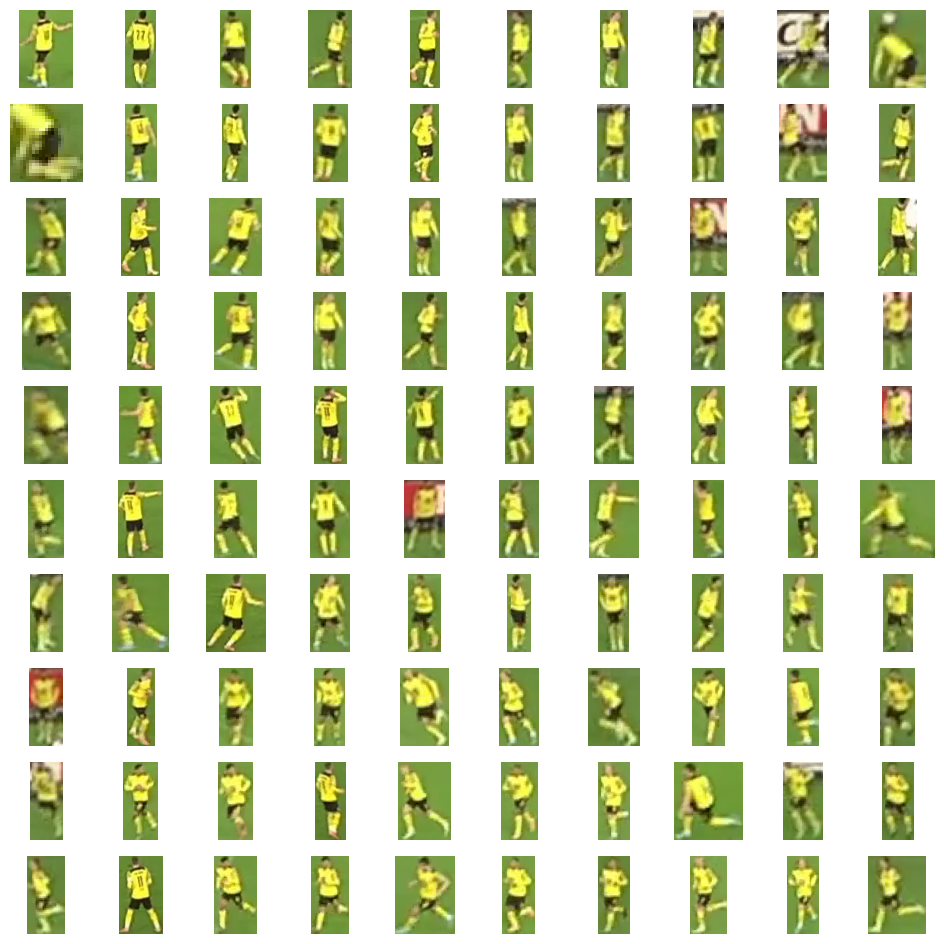

In [57]:
sv.plot_images_grid(team_0[:100], grid_size=(10, 10))

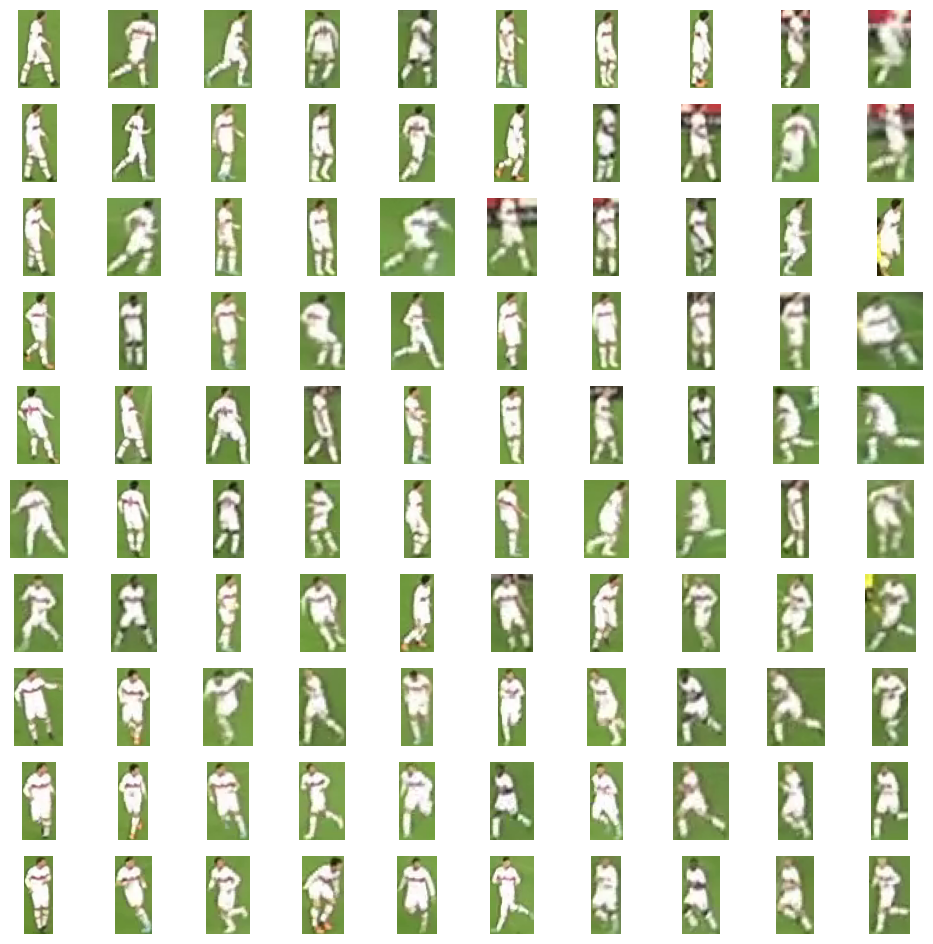

In [58]:
sv.plot_images_grid(team_1[:100], grid_size=(10, 10))